# Day 16(M4 Day03) 실습 — Self-Reflection 루프

**목표**: 생성-비평-수정 루프를 만들고, 멈춤 조건(품질 기준·최대 반복)을 조절하며, 개선 전/후 품질을 비교한다.
**구성**: Part 1 생성-비평-수정 루프(+파싱·State 오류 2종) → Part 2 멈춤 조건 조절(+제품 소개 문구 도메인 반복) → Part 3 개선 비교(+구조화 출력 업그레이드+면접 답변 자기 개선 코치)

> **참고:** 실습 전 가상환경 활성화, `.env`의 `OPENAI_API_KEY`를 확인한다. 새 패키지는 없다.

## 0. 환경 준비

In [1]:
import os, re
os.environ["LANGSMITH_TRACING"] = "false"
os.environ["LANGCHAIN_TRACING_V2"] = "false"

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)   # temperature=0: 재현성

print("준비 완료")

준비 완료


## Part 1. 생성-비평-수정 루프 — 기초

완성 코드를 직접 쳐서 초안을 스스로 비평하고 고쳐 쓰는 루프를 만든다.

### 1-1. State 정의

과제·초안·비평·점수·반복 횟수·로그를 담는다.

In [ ]:
# TODO: MAX_ITER=3, PASS=9를 정하고, task·draft·critique·score(int)·n(int)·log(list)를
#       담는 State(TypedDict)를 정의하세요
MAX_ITER = 3
PASS = 9

class State(TypedDict):
    task : str
    draft : str
    critique : str
    score : int
    n : int
    log : list

print("State 정의 완료")

State 정의 완료


### 1-2. critique 노드

LLM이 "점수|개선점" 형식으로 답하게 하고 파싱한다.

In [5]:
# TODO: llm에게 "과제·글"을 주고 "점수|개선점" 형식으로 평가받아 r에 저장한 뒤
#       '|'로 나눠 score(정수)·critique를 만들고 log에 점수를 추가해 반환하는
#       critique_node(s) 함수를 만드세요

def critique_node(s):
    # 점수|개선점 형식으로 답한다
    r = llm.invoke(
        f"""
            과제 : {s['task']} 
            글 : {s['draft']}
            이 글을 0~10점 척도로 엄격히 평가합니다. 그리고 한 문장으로 개선점을 작성하세요
            형식 : 점수|개선점
        """
    ).content

    parts = r.split("|",1) # 점수, 개선점 리스트
    score = int(re.findall(r'\d+',parts[0])[0])
    critique = parts[1].strip() if len(parts) >1 else ""
    return ({"score":score , "critique":critique, "log":s["log"] + [f" -> {score}점"]})


### 1-3. revise 노드

비평을 반영해 다시 쓴다.

In [6]:
# TODO: task·현재 draft·critique를 llm에게 주어 3문장 이내로 고친 draft를 받고,
#       n을 1 늘리고 log에 수정 기록을 추가해 반환하는 revise_node(s) 함수를 만드세요

def revise_node(s):
    draft = llm.invoke(
        f"""
            과제 : {s['task']} 
            현재 글 :{s['draft']}
            비평 : {s['critique']}

            비평을 반영한 3문장 이내로 현재 글을 다시 씁니다. 고친 글만 출력하세요
        """
    ).content

    return {"draft":draft, "n": s["n"]+1 , "log": [f"{s['n']+1}회 수정"]}

### 1-4. 조건 엣지로 루프 연결

통과 또는 최대 반복이면 종료, 아니면 다시 revise로.

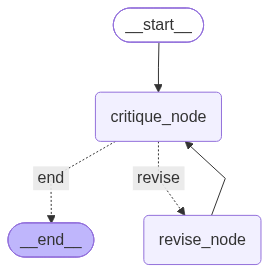

In [16]:
# TODO: score>=PASS 또는 n>=MAX_ITER면 "end", 아니면 "revise"를 반환하는 route 함수를 만드세요
def route(s):
    if s["score"]>= PASS or s["n"] >= MAX_ITER:
        return "end"
    return "revise"

# TODO: critique 다음에 route로 분기해 "revise"/"end"로 보내는 add_conditional_edges를 만들고
#       revise에서 다시 critique로 돌아가는 add_edge를 추가하세요

g = StateGraph(State)
g.add_node("critique_node",critique_node)
g.add_node("revise_node",revise_node)

g.add_edge(START,"critique_node")
g.add_conditional_edges("critique_node", route, {"revise": "revise_node", "end": END})
g.add_edge("revise_node","critique_node")



app = g.compile()
app

### 1-5. 실행·점수 변화 관찰

부실한 초안으로 시작해 점수가 오르는지 본다.

In [17]:
BAD = "재귀는 자기 자신을 부르는 거임. 어렵다."
# TODO: 위 BAD를 초안으로 하는 초기 State로 app.invoke를 실행해 result에 저장하세요

app.invoke({"task": "초등생도 이해할 수 있도록 '재귀'라는 용어를 3문장 이내로 쉽게 설명하세요",
            "draft": BAD,
            "critique": "",
            "score" : 0,
            "n" : 0,
            "log":["[초안] "+BAD]})


{'task': "초등생도 이해할 수 있도록 '재귀'라는 용어를 3문장 이내로 쉽게 설명하세요",
 'draft': '재귀는 어떤 것이 자기 자신을 다시 부르는 것을 말해. 예를 들어, 거울 속의 나를 다시 보는 것처럼, 재귀는 문제를 작은 부분으로 나누어 같은 방법으로 해결하는 거야. 예를 들어, 큰 나무를 자를 때 작은 가지부터 자르는 것처럼, 복잡한 문제도 이렇게 쉽게 풀 수 있어!',
 'critique': "재귀의 개념을 더 명확하게 설명하기 위해 '자기 자신을 다시 부르는 것' 대신 '문제를 해결하기 위해 같은 방법을 반복하는 것'으로 표현하면 좋겠습니다.",
 'score': 8,
 'n': 3,
 'log': ['3회 수정', ' -> 8점']}

### 1-6. 오류 대응 ① — 비평 형식이 깨지면?

LLM이 "점수|개선점" 형식을 안 지키고 그냥 문장으로만 답하면 파싱이 어떻게 되는지 확인한다.

In [ ]:
fake_response = "이 글은 괜찮은 편입니다. 조금 더 구체적인 사례가 있으면 좋겠습니다."
try:
    # TODO: fake_response를 "|"로 나누고 첫 부분에서 숫자를 뽑아 score를 만들어보세요
    #       (형식이 깨진 응답이라 실제로 어떻게 되는지 확인)


    print("파싱 성공(예상 밖):", score)
except Exception as e:
    print("오류 발생:", type(e).__name__, "-", e)

> **주의:** 결과는 실제 실행에서 직접 확인한다. LLM이 지시한 형식을 항상 정확히 지킨다는 보장은 없다 — 문자열 파싱은 이런 형식 이탈에 취약하다. Part 3에서 구조화 출력으로 이 문제를 근본적으로 해결한다.

### 1-7. 오류 대응 ② — 필수 State 키를 빠뜨리면?

`log`를 안 채우고 실행하면 `critique_node`가 어떻게 되는지 확인한다.

In [ ]:
try:
    # TODO: log 키를 빼고 app.invoke를 실행해보세요
    #       ({"task": "테스트", "draft": BAD, "critique": "", "score": 0, "n": 0})


    print("실행 성공(예상 밖):", bad_result)
except Exception as e:
    print("오류 발생:", type(e).__name__, "-", e)

> **주의:** 결과는 실제 실행에서 직접 확인한다. `critique_node`가 `s["log"] + [...]`로 `log`에 접근하는데, State에 `log`가 없으면 그 시점에 오류가 난다.

### 관찰 정리

- 비평 노드는 무엇을, 수정 노드는 무엇을 하나?
- 1-6·1-7에서 확인한 두 오류 중, 실무에서 더 자주 마주칠 만한 것은 어느 쪽일까?

## Part 2. 멈춤 조건 조절 — 응용

품질 기준(PASS)과 최대 반복(MAX_ITER)이 각각 언제 루프를 멈추는지 관찰한다.

### 2-1. 품질 기준으로 멈추기 (PASS=8)

달성 가능한 8점을 목표로 두면 1회 수정에 통과해 멈춘다.

In [ ]:
# TODO: 전역 PASS를 8로, MAX_ITER를 3으로 바꾸고 같은 BAD 초안으로 app.invoke를 다시 실행해
#       result_p8에 저장하세요




### 2-2. 최대 반복으로 멈추기 (PASS=9, MAX_ITER=2)

9점을 목표로 두면 8점 한계라 통과 못 하고 최대 반복에서 멈춘다.

In [ ]:
# TODO: 전역 PASS를 9로, MAX_ITER를 2로 바꾸고 같은 BAD 초안으로 app.invoke를 다시 실행해
#       result_p9에 저장하세요



### 관찰 정리

| 설정 | 멈춘 이유(예상) |
| --- | --- |
| PASS=8 | 품질 기준 도달 |
| PASS=9, MAX_ITER=2 | 최대 반복 도달 |

### 2-3. 다른 도메인 반복 — 제품 소개 문구 자기 개선

같은 루프(critique·revise·route)를 다른 과제에도 그대로 적용해본다. 그래프 구조는 바꾸지 않고, 초안·과제만 바꾼다.

In [ ]:
PASS = 8
MAX_ITER = 3

PRODUCT_BAD = "이 제품은 좋습니다. 사서 써보세요."
# TODO: PRODUCT_BAD를 초안으로, "무선 이어폰 제품 소개 문구를 3문장 이내로 매력적으로 작성"을
#       과제로 하는 초기 State로 app.invoke를 실행해 result_product에 저장하세요



### 관찰 정리

- 재귀 설명 과제와 제품 소개 문구 과제 모두에서, 같은 그래프 구조로 점수가 올랐는가?
- 과제가 바뀌어도 critique·revise·route 함수는 그대로 재사용됐다 — 무엇 덕분인가?

## Part 3. 미니 프로젝트 — 개선 전/후 비교

Self-Reflection 루프로 초안을 개선하고, 전/후 점수를 비교한다.

### 3-1. 개선 전/후 비교표

### 관찰

| 구분 | 글 | 점수 |
| --- | --- | --- |
| 개선 전(초안) | "재귀는 자기 자신을 부르는 거임. 어렵다." | 5 |
| 개선 후(최종) | (2-1 결과) | 8 |

> **참고:** 점수는 LLM 채점이라 실행마다 조금 다를 수 있다. "초안보다 최종이 낫다"는 흐름은 유지된다.

## Part 3-확장. 구조화 출력 업그레이드 + M1 통합 — 면접 답변 자기 개선 코치

1-2의 `"점수|개선점"` 문자열 파싱을 **구조화 출력**(M3 Day03 방식)으로 바꾸고, 지원자가 쓴 면접 답변 초안을 스스로 비평·수정해주는 기능으로 확장한다. M1 Day04의 방어 로직도 그대로 붙인다.

### 구조화된 평가 모델

In [ ]:
from pydantic import BaseModel, Field

# TODO: score(0~10)·problems(str)·improvement(str)를 담는 Evaluation(BaseModel)을 정의하고
#       llm.with_structured_output(Evaluation)으로 evaluator_llm을 만드세요




print("구조화된 평가 모델 준비 완료")

### 방어 로직 (M1 Day04 재사용)

인젝션 방어는 M1 Day04에서 만든 것을 그대로 가져온다.

In [ ]:
# TODO: M1 Day04의 위험 문구·금지어 목록과 input_guard·output_guard를 옮겨오세요






### 면접 답변 자기 개선 루프

In [ ]:
class AnswerState(TypedDict):
    question: str
    draft: str
    score: int
    critique: str
    improvement: str
    n: int
    log: list

def answer_critique(s):
    result = evaluator_llm.invoke(
        f"면접 질문: {s['question']}\n지원자의 답변: {s['draft']}\n\n"
        "이 답변을 면접관 관점에서 0~10점으로 엄격히 평가하고, "
        "부족한 점과 구체적인 개선 방법을 알려줘라."
    )
    return {"score": result.score, "critique": result.problems, "improvement": result.improvement,
            "log": s["log"] + [f"{s['n']}회차: {result.score}점"]}

# TODO: 면접 질문·현재 답변·부족한 점·개선 방법을 llm에게 주어 다시 작성하게 하고,
#       n을 1 늘리는 answer_revise 함수를 만드세요




def answer_route(s):
    return "end" if (s["score"] >= 8 or s["n"] >= 3) else "revise"

ga = StateGraph(AnswerState)
ga.add_node("critique", answer_critique)
ga.add_node("revise", answer_revise)
ga.add_edge(START, "critique")
ga.add_conditional_edges("critique", answer_route, {"revise": "revise", "end": END})
ga.add_edge("revise", "critique")
answer_graph = ga.compile()

def improve_interview_answer(question, draft_answer):
    if input_guard(draft_answer):
        return "[입력 차단] 위험한 요청으로 감지되었습니다."
    # TODO: question·draft_answer로 초기 State를 만들어 answer_graph를 invoke해 result를 만드세요



    if not output_guard(result["draft"]):
        return "[출력 차단] 부적절한 응답이 감지되었습니다."
    for line in result["log"]:
        print(line)
    return result["draft"]

### 최종 테스트

In [ ]:
weak_answer = "저는 이 회사가 유명해서 지원했습니다. 열심히 하겠습니다."
print("[개선 전]", weak_answer)
print()
final_answer = improve_interview_answer("왜 우리 회사에 지원하셨나요?", weak_answer)
print("\n[개선 후]", final_answer)
print()
print("[인젝션 시도]")
# TODO: 인젝션을 시도하는 draft_answer로 improve_interview_answer를 호출해보세요

### M4 Day03 정리

**확인 질문**
- 구조화 출력으로 바꾸니 1-6에서 겪은 파싱 문제가 근본적으로 해결됐는가? 왜 그런가?
- `improve_interview_answer`에서 Self-Reflection(오늘)·구조화 출력(M3 Day03)·방어 로직(M1 Day04)이 각각 어떤 역할을 하는가?

## 확인 문제

1. Self-Reflection 루프에서 critique와 revise는 각각 무엇을 하는가?
2. 1-6·1-7에서 확인한 두 오류는 각각 무엇 때문에 생겼는가?
3. Part 2와 Part 2의 도메인 반복에서, 과제가 바뀌어도 멈춤 조건의 원리는 그대로였는가?
4. 품질 기준과 최대 반복 중 하나가 없으면 어떤 문제가 생기는가?
5. `improve_interview_answer`가 구조화 출력을 쓰면서 좋아진 점은 무엇인가?